# 4.2 Demand Prediction

In this notebook we implement Neural Networks (NNs) to predict taxi trip demand in chicago. Additionally, we compare the performances of the NNs across different complexity levels.

For NNs there are 2 "main" complexity interpretations:
- depth: number of hidden layers
- width: number of nodes per layer
- (more complex activation function) - maybe as an extra
- (more complex optimizer) - maybe as an extra

So we decide to test 3 different NN structures:

__baseline model__:
- hidden layers: 2
- nodes per layer: 64

__wider model__:
- hidden layers: 2
- nodes per layer: 256

__deeper model__:
- hidden layers: 8
- nodes per layer: 64

For better comparison, we will test all three architectures with the same shared configurations.

Before training any NN, we establish two simple **benchmarks** to contextualise the results:

1. **Historical-mean predictor** — for each hexagon × hour-of-day pair, predict the mean `trip_count` seen in the training set. Unseen combinations fall back to the global training mean. This captures the dominant demand pattern (location + time-of-day) without any learning.
2. **Ridge regression** — a linear model fit on the same scaled feature matrix. Trained on log₁⁺ demand and back-transformed at evaluation time (same target encoding as the NNs). This shows how much a linear model can do before adding any non-linearity or depth.

## Table of Contents

- [4.2.1 Data Information](#421-data-information)
- [4.2.2 Model Configurations](#422-model-configurations)
- [4.2.3 Model Definition](#423-model-definition)
- [4.2.4 Hyperparameter Search Definition (GridSearch)](#424-hyperparameter-search-definition-gridsearch)
- [4.2.5 Visualization: Model Architecture](#425-visualization-model-architecture)
- [4.2.6 Train / Val / Test Split](#426-train--val--test-split)
- [4.2.7 Feature Preparation](#427-feature-preparation)
- [4.2.8 Benchmark Models](#428-benchmark-models)
- [4.2.9 Baseline Model — Training](#429-baseline-model--training)
  - [4.2.9 Baseline Model — Evaluation](#429-baseline-model--evaluation)
- [4.2.10 Hyperparameter Search — Baseline Model](#4210-hyperparameter-search--baseline-model)
  - [4.2.10 Tuned Baseline — Training](#4210-tuned-baseline--training)
  - [4.2.10 Tuned Baseline — Evaluation](#4210-tuned-baseline--evaluation)
- [4.2.11 Deeper Model — Training](#4211-deeper-model--training)
  - [4.2.11 Deeper Model — Evaluation](#4211-deeper-model--evaluation)
- [4.2.12 Hyperparameter Search — Deeper Model](#4212-hyperparameter-search--deeper-model)
  - [4.2.12 Wider Model — Training](#4212-wider-model--training)
  - [4.2.12 Wider Model — Evaluation](#4212-wider-model--evaluation)
  - [4.2.12 Hyperparameter Search — Wider Model](#4212-hyperparameter-search--wider-model)
  - [4.2.12 Tuned Wider — Training](#4212-tuned-wider--training)
  - [4.2.12 Tuned Wider — Evaluation](#4212-tuned-wider--evaluation)

In [41]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Import packages                         #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #


import pandas as pd
# import matplotlib.pyplot as plt

# modeling
import copy
import random
import types
import numpy as np
import optuna
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score as _r2

# evaluation
import datetime

# visualization
from torchinfo import summary
import matplotlib.pyplot as plt

# reset working dir
import os
from pathlib import Path


In [42]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Reset working directory                 #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

import __main__
_nb = getattr(__main__, "__vsc_ipynb_file__", None) or os.environ.get("JPY_SESSION_NAME")
_start = Path(_nb).resolve().parent if _nb else Path.cwd()
os.chdir(next(p for p in [_start, *_start.parents] if (p / "pyproject.toml").exists()))
print(f"Working directory: {os.getcwd()}")

Working directory: /Users/anthony/Documents/Dokumente – MacBook Pro von Anthony/UNI/AAA/AAA_TA_2026


In [43]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Load data                               #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

data = pd.read_parquet("data/aggregated/hexagon/demand_hex_24h_low.parquet")

In [44]:
data

,time_bucket,bucket_index,pickup_h3_res6,area_type,trip_count,active_taxis,avg_idle_time,avg_trip_duration,avg_trip_distance,avg_fare,...,dist_to_nearest_train_station_km,dist_to_nearest_stadium_km,train_station_per_km2,restaurants_per_km2,bars_and_clubs_per_km2,hotels_per_km2,hospitals_per_km2,universities_per_km2,attractions_per_km2,poi_density_total_per_km2
0,2025-01-01,482136,862664197ffffff,residential,16,15,38.076923,1170.437500,10.839375,28.593750,...,3.463863,5.190882,0.000000,0.412471,0.219985,0.000000,0.000000,0.000000,0.027498,0.659954
1,2025-01-01,482136,86266419fffffff,residential,1,1,45.000000,1380.000000,8.800000,25.250000,...,0.770790,5.836479,0.055042,0.137605,0.055042,0.055042,0.000000,0.000000,0.027521,0.330253
2,2025-01-01,482136,8626641b7ffffff,residential,6,6,22.500000,1425.666667,10.806667,28.458333,...,3.428506,4.626667,0.027470,0.247232,0.027470,0.000000,0.000000,0.000000,0.000000,0.302173
3,2025-01-01,482136,862664527ffffff,airport,265,134,87.305389,1445.781132,12.467358,33.056604,...,2.529989,4.162891,0.027462,0.631634,0.302086,0.000000,0.000000,0.000000,0.000000,0.961182
4,2025-01-01,482136,86266452fffffff,residential,2,2,0.000000,2130.000000,17.800000,44.750000,...,2.695998,5.548927,0.054970,0.659643,0.137426,0.384792,0.054970,0.027485,0.027485,1.346772
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12040,2025-12-31,490872,862664dafffffff,residential,5,5,30.000000,1365.000000,7.588000,22.774000,...,3.960234,4.291273,0.000000,0.027329,0.000000,0.000000,0.000000,0.000000,0.000000,0.027329
12041,2025-12-31,490872,862759347ffffff,airport,611,462,122.920792,2086.099836,14.661211,38.723142,...,2.892475,2.057285,0.136860,1.176998,0.301092,0.520069,0.000000,0.000000,0.027372,2.162392
12042,2025-12-31,490872,86275934fffffff,airport,612,449,128.810241,2002.815359,14.596144,38.289804,...,1.220338,2.809967,0.191761,1.068385,0.465706,0.383523,0.000000,0.000000,0.027394,2.136770
12043,2025-12-31,490872,86275935fffffff,airport,175,159,132.580645,2085.954286,14.708171,38.737771,...,1.340206,7.539746,0.054799,0.273996,0.054799,0.027400,0.000000,0.000000,0.000000,0.410994


## 4.2.1 Data Information

In [45]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Data Information                        #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

# How many times does each row repeat when ignoring the time bucket?
# bucket_index is also excluded as it is a numeric encoding of the time bucket.
cols_no_time = [c for c in data.columns if c not in ('time_bucket', 'bucket_index')]
counts = data[cols_no_time].value_counts()

n_total    = len(data)
n_unique   = len(counts)
n_repeated = int((counts > 1).sum())

print(f"Total rows                    : {n_total:>10,}")
print(f"Unique combinations (no time) : {n_unique:>10,}")
print(f"Combinations appearing >1x    : {n_repeated:>10,}")
print(f"Avg repetitions per combo     : {n_total / n_unique:>10.2f}x")
print(f"\nRepetition count distribution:")
dist = counts.value_counts().sort_index()
for k, v in dist.items():
    print(f"  appears {k:>3}x : {v:>8,} combinations")

# How often does each hexagon + hour-of-day combination appear?
hex_hour_counts = data.groupby(['pickup_h3_res6', 'hour_of_day']).size()

print(f"\n--- Hexagon × Hour-of-day ---")
print(f"Unique hex × hour combinations : {len(hex_hour_counts):>8,}")
print(f"Avg appearances per combo      : {hex_hour_counts.mean():>8.1f}x")
print(f"Min appearances                : {hex_hour_counts.min():>8,}")
print(f"Max appearances                : {hex_hour_counts.max():>8,}")

# Zero-demand rows
n_zero        = int((data['trip_count'] == 0).sum())
pct_zero      = 100.0 * n_zero / n_total
print(f"\n--- Demand ---")
print(f"Zero-demand rows               : {n_zero:>8,}  ({pct_zero:.1f}%)")
print(f"Non-zero-demand rows           : {n_total - n_zero:>8,}  ({100 - pct_zero:.1f}%)")

Total rows                    :     12,045
Unique combinations (no time) :     12,045
Combinations appearing >1x    :          0
Avg repetitions per combo     :       1.00x

Repetition count distribution:
  appears   1x :   12,045 combinations

--- Hexagon × Hour-of-day ---
Unique hex × hour combinations :       33
Avg appearances per combo      :    365.0x
Min appearances                :      365
Max appearances                :      365

--- Demand ---
Zero-demand rows               :      848  (7.0%)
Non-zero-demand rows           :   11,197  (93.0%)


In [46]:
data.head()

,time_bucket,bucket_index,pickup_h3_res6,area_type,trip_count,active_taxis,avg_idle_time,avg_trip_duration,avg_trip_distance,avg_fare,...,dist_to_nearest_train_station_km,dist_to_nearest_stadium_km,train_station_per_km2,restaurants_per_km2,bars_and_clubs_per_km2,hotels_per_km2,hospitals_per_km2,universities_per_km2,attractions_per_km2,poi_density_total_per_km2
0,2025-01-01,482136,862664197ffffff,residential,16,15,38.076923,1170.437500,10.839375,28.593750,...,3.463863,5.190882,0.000000,0.412471,0.219985,0.000000,0.00000,0.000000,0.027498,0.659954
1,2025-01-01,482136,86266419fffffff,residential,1,1,45.000000,1380.000000,8.800000,25.250000,...,0.770790,5.836479,0.055042,0.137605,0.055042,0.055042,0.00000,0.000000,0.027521,0.330253
2,2025-01-01,482136,8626641b7ffffff,residential,6,6,22.500000,1425.666667,10.806667,28.458333,...,3.428506,4.626667,0.027470,0.247232,0.027470,0.000000,0.00000,0.000000,0.000000,0.302173
3,2025-01-01,482136,862664527ffffff,airport,265,134,87.305389,1445.781132,12.467358,33.056604,...,2.529989,4.162891,0.027462,0.631634,0.302086,0.000000,0.00000,0.000000,0.000000,0.961182
4,2025-01-01,482136,86266452fffffff,residential,2,2,0.000000,2130.000000,17.800000,44.750000,...,2.695998,5.548927,0.054970,0.659643,0.137426,0.384792,0.05497,0.027485,0.027485,1.346772


## 4.2.2 Model Configurations

In [47]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Shared Configs                          #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

# --- optimization ---
OPTIMIZER          = "sgd"
LEARNING_RATE      = 5e-5
WEIGHT_DECAY       = 0.0     # decoupled L2 (AdamW); per-arch values come from the HP search
BATCH_SIZE         = 1024
MAX_EPOCHS         = 200

# --- loss / output ---
LOSS               = "mae"  # "mse" | "mae" | "poisson_nll" | "nb_nll" (count NLLs: raw-count targets, log-rate output)
OUTPUT_UNITS       = 1
OUTPUT_ACTIVATION  = "softplus"

# --- layer defaults ---
HIDDEN_ACTIVATION  = "relu"
WEIGHT_INIT        = "he_normal"

# --- early stopping ---
EARLY_STOPPING     = True
MONITOR            = "val_loss"
PATIENCE           = 10

# --- data handling ---
SPLIT              = "random"
SCALER_FIT_ON      = "train_only"

# --- hex embedding ---
HEX_EMBED_DIM      = 16      # learned embedding dim per hexagon

# --- device ---
device = "cuda" if torch.cuda.is_available() else "cpu"

# --- reproducibility ---
SEEDS              = (0,)

# --- architectures ---
ARCH_BASELINE      = (2, 64)
ARCH_WIDER         = (2, 256)
ARCH_DEEPER        = (8, 64)

config = types.SimpleNamespace(
    LOSS           = LOSS,
    OPTIMIZER      = OPTIMIZER,
    LEARNING_RATE  = LEARNING_RATE,
    WEIGHT_DECAY   = WEIGHT_DECAY,
    BATCH_SIZE     = BATCH_SIZE,
    MAX_EPOCHS     = MAX_EPOCHS,
    EARLY_STOPPING = EARLY_STOPPING,
    PATIENCE       = PATIENCE,
    OUTPUT_UNITS   = OUTPUT_UNITS,
    HEX_EMBED_DIM  = HEX_EMBED_DIM,
)

ARCH_NAMES = {ARCH_BASELINE: "baseline", ARCH_WIDER: "wide", ARCH_DEEPER: "deep"}

HP_SEARCH_SEEDS        = SEEDS   # same single seed for hp search and final training
HP_PATIENCE            = 5
BEST_HP                = {}

HP_LR_DECADES  = [2e-5, 5e-5, 8e-5, 2e-4, 5e-4, 8e-4, 2e-3, 5e-3, 8e-3, 2e-2, 5e-2, 8e-2]   # step 1: one representative per decade
HP_WD_DECADES  = [0.0, 5e-4, 5e-3, 5e-2]    # 0.0 = unregularized control
HP_FINE_STEPS  = list(range(1, 10))             # step 2: multipliers inside the winning decade


## 4.2.3 Model Definition

In [48]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Model + Training Utilities              #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

def nb_nll_loss(log_mu, y, log_theta):
    """NB2 negative log-likelihood: mean μ = exp(log_mu), Var = μ + μ²/θ, θ = exp(log_theta)."""
    theta   = torch.exp(log_theta)
    mu      = torch.exp(log_mu)
    log_t_m = torch.log(theta + mu)
    ll = (torch.lgamma(y + theta) - torch.lgamma(theta) - torch.lgamma(y + 1.0)
          + theta * (log_theta - log_t_m)
          + y     * (log_mu    - log_t_m))
    return -ll.mean()


class DemandBaseline(nn.Module):
    def __init__(self, input_dim, n_layers, width, n_hex, embed_dim):
        super().__init__()
        self.hex_embed = nn.Embedding(n_hex, embed_dim)
        nn.init.normal_(self.hex_embed.weight, std=0.01)

        layers = []
        in_dim = input_dim + embed_dim
        for _ in range(n_layers):
            linear = nn.Linear(in_dim, width)
            nn.init.kaiming_normal_(linear.weight, nonlinearity="relu")
            nn.init.zeros_(linear.bias)
            layers += [linear, nn.ReLU()]
            in_dim = width
        out = nn.Linear(in_dim, config.OUTPUT_UNITS)
        nn.init.kaiming_normal_(out.weight, nonlinearity="relu")
        nn.init.zeros_(out.bias)
        layers.append(out)
        if getattr(config, "LOSS", "mse") not in ("poisson_nll", "nb_nll"):
            layers.append(nn.Softplus())   # output = log1p(y) estimate
        # else: output = unconstrained log-rate log(μ), consumed by the Poisson/NB NLL
        self.net = nn.Sequential(*layers)

        if getattr(config, "LOSS", "mse") == "nb_nll":
            # NB2 dispersion, trained jointly with the network weights
            self.log_theta = nn.Parameter(torch.zeros(()))

    def forward(self, x, hex_idx):
        emb = self.hex_embed(hex_idx)          # (batch, embed_dim)
        x   = torch.cat([x, emb], dim=-1)      # (batch, input_dim + embed_dim)
        return self.net(x).squeeze(-1)


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def train_model(arch, X_train, y_train, X_val, y_val,
                hex_train, hex_val,
                seed=0, device="cpu", verbose=True, lr=None,
                batch_size=None, patience=None, weight_decay=None,
                embed_dim=None, epoch_cb=None):
    if seed is not None:
        set_seed(seed)
    n_layers, width = arch
    _embed_dim  = embed_dim  if embed_dim  is not None else config.HEX_EMBED_DIM
    _batch_size = batch_size if batch_size is not None else config.BATCH_SIZE
    _patience   = patience   if patience   is not None else config.PATIENCE
    model = DemandBaseline(X_train.shape[1], n_layers, width, N_HEX, _embed_dim).to(device)

    _loss_name = getattr(config, "LOSS", "mse")
    if _loss_name == "mse":
        loss_fn = nn.MSELoss()
    elif _loss_name == "mae":
        loss_fn = nn.L1Loss()
    elif _loss_name == "poisson_nll":
        loss_fn = nn.PoissonNLLLoss(log_input=True, full=False)   # model outputs log-rate; exp() applied internally
    elif _loss_name == "nb_nll":
        def loss_fn(log_mu, y):   # model outputs log-mean; dispersion θ trained jointly
            return nb_nll_loss(log_mu, y, model.log_theta)
    else:
        raise ValueError(f"unknown config.LOSS: {_loss_name!r}")

    _lr             = lr if lr is not None else config.LEARNING_RATE
    _wd             = weight_decay if weight_decay is not None else getattr(config, 'WEIGHT_DECAY', 0.0)
    _optimizer_name = getattr(config, 'OPTIMIZER', 'adam').lower()
    if _optimizer_name == 'sgd':
        optimizer = torch.optim.SGD(model.parameters(), lr=_lr, momentum=0.9, weight_decay=_wd)
    elif _optimizer_name == 'rmsprop':
        optimizer = torch.optim.RMSprop(model.parameters(), lr=_lr, weight_decay=_wd)
    else:
        # AdamW = decoupled weight decay; plain Adam's L2 gets rescaled by the adaptive LR
        optimizer = torch.optim.AdamW(model.parameters(), lr=_lr, weight_decay=_wd)

    train_dl = DataLoader(
        TensorDataset(
            torch.as_tensor(X_train,   dtype=torch.float32),
            torch.as_tensor(hex_train, dtype=torch.long),
            torch.as_tensor(y_train,   dtype=torch.float32),
        ),
        batch_size=_batch_size,
        shuffle=True,
    )
    X_val_t   = torch.as_tensor(X_val,   dtype=torch.float32).to(device)
    hex_val_t = torch.as_tensor(hex_val, dtype=torch.long).to(device)
    y_val_t   = torch.as_tensor(y_val,   dtype=torch.float32).to(device)

    best_val, best_state, wait = float("inf"), None, 0
    best_train_loss = float("inf")
    ep_width        = len(str(config.MAX_EPOCHS))

    for epoch in range(config.MAX_EPOCHS):
        if verbose:
            print(f"Epoch {epoch + 1:{ep_width}d}/{config.MAX_EPOCHS}")

        model.train()
        running_loss, n_batches = 0.0, 0
        for xb, hb, yb in train_dl:
            xb, hb, yb = xb.to(device), hb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = loss_fn(model(xb, hb), yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            n_batches    += 1
        train_loss = running_loss / n_batches

        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(X_val_t, hex_val_t), y_val_t).item()

        if not np.isfinite(val_loss):
            if verbose:
                print(f"  ↳ diverged (val_loss={val_loss}) at epoch {epoch + 1}")
            break

        if epoch_cb is not None:
            epoch_cb(epoch, val_loss)   # hp-search hook; may raise to abort the run

        improved = val_loss < best_val
        if improved:
            best_val, best_state, wait = val_loss, copy.deepcopy(model.state_dict()), 0
            best_train_loss = train_loss
        else:
            wait += 1

        marker = " ✓" if improved else f"  (no improvement {wait}/{_patience})"
        if verbose:
            print(f"  loss: {train_loss:.4f}  val_loss: {val_loss:.4f}{marker}")

        if config.EARLY_STOPPING and wait >= _patience:
            if verbose:
                print(f"\n  ↳ early stop at epoch {epoch + 1}"
                      f"  best_val={best_val:.4f}  best_train={best_train_loss:.4f}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    # else: run diverged before any improvement; best_val stays inf so the
    # HP search ranks the combo last instead of crashing
    return model, best_val, best_train_loss


## 4.2.4 Hyperparameter Search Definition (GridSearch)

In [49]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# HP Search Utility (Optuna GridSampler)  #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

optuna.logging.set_verbosity(optuna.logging.WARNING)


def run_hp_search(arch, X_train, y_train, X_val, y_val,
                  hex_train, hex_val,
                  device='cpu',
                  lr_candidates=None, wd_candidates=None):
    """Optuna grid search (GridSampler) over lr and weight decay.

    Every lr × wd combination from the candidate lists is evaluated exactly
    once, so this is a true exhaustive grid search; the median pruner aborts
    combinations whose validation loss is clearly worse than the running
    median. Each trial trains one model per seed in HP_SEARCH_SEEDS and is
    scored by the mean validation loss, so the search is reproducible.
    """
    lr_candidates = lr_candidates or HP_LR_DECADES
    wd_candidates = wd_candidates if wd_candidates is not None else HP_WD_DECADES
    arch_label    = ARCH_NAMES.get(arch, str(arch))
    search_space  = {'lr': list(lr_candidates), 'weight_decay': list(wd_candidates)}
    n_trials      = len(lr_candidates) * len(wd_candidates)

    def objective(trial):
        lr = trial.suggest_categorical('lr', lr_candidates)
        wd = trial.suggest_categorical('weight_decay', wd_candidates)

        def epoch_cb(epoch, val_loss):
            # pruning is judged on the first seed's run only
            trial.report(val_loss, epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()

        val_losses = []
        for j, seed in enumerate(HP_SEARCH_SEEDS):
            _, val_loss, _ = train_model(
                arch, X_train, y_train, X_val, y_val,
                hex_train, hex_val,
                seed=seed, device=device, verbose=False,
                lr=lr, weight_decay=wd, patience=HP_PATIENCE,
                epoch_cb=epoch_cb if j == 0 else None,
            )
            val_losses.append(val_loss)
        return float(np.mean(val_losses))

    print(f'HP Search — {arch_label}  |  grid {len(lr_candidates)}×{len(wd_candidates)}'
          f' = {n_trials} combos  |  seeds={HP_SEARCH_SEEDS}  |  patience={HP_PATIENCE}\n')
    print(f"{'#':>4}  {'lr':>10}  {'wd':>10}  {'mean val':>10}  state")
    print('-' * 50)

    def log_trial(study, trial):
        wd  = trial.params.get('weight_decay', 0.0)
        val = trial.value if trial.value is not None else float('nan')
        print(f"{trial.number + 1:>4}  {trial.params['lr']:>10.2e}  {wd:>10.2e}"
              f"  {val:>10.4f}  {trial.state.name.lower()}")

    study = optuna.create_study(
        direction='minimize',
        sampler=optuna.samplers.GridSampler(search_space, seed=HP_SEARCH_SEEDS[0]),
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=5),
    )
    study.optimize(objective, n_trials=n_trials, callbacks=[log_trial])

    complete = [t for t in study.trials
                if t.state == optuna.trial.TrialState.COMPLETE]
    print('\n--- Top 5 ---')
    for t in sorted(complete, key=lambda t: t.value)[:5]:
        print(f"  lr={t.params['lr']:.2e}"
              f"  wd={t.params.get('weight_decay', 0.0):.2e}"
              f"  val_loss={t.value:.4f}")

    p = study.best_trial.params
    BEST_HP[arch] = {'lr': float(p['lr']),
                     'weight_decay': float(p.get('weight_decay', 0.0))}
    print(f'\nBEST_HP[{arch_label}] = {BEST_HP[arch]}')
    return BEST_HP[arch]


def fine_candidates(best, steps=None):
    """Fine grid inside the decade of `best`, e.g. 5e-4 -> [2e-4, 4e-4, 5e-4, 6e-4, 8e-4].

    best = 0.0 (unregularized weight decay) has no decade and stays [0.0].
    """
    if best == 0.0:
        return [0.0]
    steps = steps or HP_FINE_STEPS
    decade = 10.0 ** int(np.floor(np.log10(best)))
    return [float(f'{s * decade:.0e}') for s in steps]


def run_hp_search_2step(arch, X_train, y_train, X_val, y_val,
                        hex_train, hex_val, device='cpu',
                        lr_decades=None, wd_decades=None):
    """Coarse-to-fine grid search: step 1 locates the best order of magnitude
    for lr and weight decay on a decade grid, step 2 runs a finer grid
    restricted to the winning decades. Both steps are exhaustive grids, so
    only rough orders of magnitude need to be known upfront."""
    lr_decades = lr_decades or HP_LR_DECADES
    wd_decades = wd_decades if wd_decades is not None else HP_WD_DECADES
    arch_label = ARCH_NAMES.get(arch, str(arch))

    print(f'=== Step 1/2 — decade grid ({arch_label}) ===\n')
    coarse = run_hp_search(arch, X_train, y_train, X_val, y_val,
                           hex_train, hex_val, device=device,
                           lr_candidates=lr_decades, wd_candidates=wd_decades)

    # keep the coarse winners in the fine grid so step 2 can never end up worse
    lr_fine = sorted(set(fine_candidates(coarse['lr']) + [coarse['lr']]))
    wd_fine = sorted(set(fine_candidates(coarse['weight_decay']) + [coarse['weight_decay']]))
    print(f'\n=== Step 2/2 — fine grid in winning decades ({arch_label}) ===')
    print(f'lr candidates: {lr_fine}')
    print(f'wd candidates: {wd_fine}\n')
    # overwrites BEST_HP[arch] with the fine-grid winner
    return run_hp_search(arch, X_train, y_train, X_val, y_val,
                         hex_train, hex_val, device=device,
                         lr_candidates=lr_fine, wd_candidates=wd_fine)


## Evaluation & Save Utilities
Shared helpers used after every training run below: `evaluate_models` computes the test-set metrics for the per-seed models of one architecture and returns the result rows, `save_results` appends them to the results CSV.

In [50]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Evaluation Utility                      #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

def evaluate_models(arch, models, train_losses, val_losses,
                    X_test, y_test, hex_test,
                    device="cpu", label=None, model_name=None,
                    hp=None, show_weight_stats=False):
    """Evaluate the per-seed models of one architecture on the held-out test set.

    hp    : optional {"lr", "weight_decay"} dict (e.g. BEST_HP[arch]);
            defaults to the shared config values.
    Returns the run_results rows for save_results().
    """
    n_layers, width = arch
    label      = label      or ARCH_NAMES.get(arch, "model").capitalize()
    model_name = model_name or ARCH_NAMES.get(arch, "unknown")
    lr = hp["lr"] if hp else config.LEARNING_RATE
    wd = hp.get("weight_decay", 0.0) if hp else getattr(config, "WEIGHT_DECAY", 0.0)

    X_test_t   = torch.as_tensor(X_test,   dtype=torch.float32).to(device)
    hex_test_t = torch.as_tensor(hex_test, dtype=torch.long).to(device)

    run_results = []
    r2_scores,     mae_scores,     rmse_scores,     nrmse_scores     = [], [], [], []
    mape_scores = []
    r2_log_scores, mae_log_scores, rmse_log_scores, nrmse_log_scores = [], [], [], []
    correct_zero_counts, false_zero_counts = [], []
    pred_min_scores, pred_max_scores = [], []
    test_losses = []

    zero_demand_count = int((y_test == 0).sum())
    zero_demand_pct   = 100.0 * zero_demand_count / len(y_test)
    mean_actual       = float(y_test.mean())
    ss_tot            = float(np.sum((y_test - mean_actual) ** 2))

    y_test_log  = np.log1p(y_test)
    mean_log    = float(y_test_log.mean())
    ss_tot_log  = float(np.sum((y_test_log - mean_log) ** 2))

    print(f"Zero-demand rows: {zero_demand_count:,} / {len(y_test):,} ({zero_demand_pct:.1f}%)")
    print(f"Mean actual test demand : {mean_actual:.4f}  (min={y_test.min():.4f}, max={y_test.max():.4f})\n")

    for i, (seed, model) in enumerate(zip(SEEDS, models)):
        model.eval()

        if show_weight_stats:
            print(f"  seed={seed} layer weight stats:")
            for name, param in model.named_parameters():
                if "weight" in name:
                    w = param.detach().cpu().numpy()
                    print(f"    {name:<14s}  shape={str(tuple(w.shape)):<12}"
                          f"  max|w|={np.abs(w).max():.4f}  mean|w|={np.abs(w).mean():.4f}  norm={np.linalg.norm(w):.4f}")

        with torch.no_grad():
            preds_raw = model(X_test_t, hex_test_t).cpu().numpy().flatten()
        preds     = np.exp(preds_raw) if IS_POISSON else np.expm1(preds_raw)
        preds_log = np.log1p(preds)
        pred_min, pred_max = float(preds.min()), float(preds.max())

        mae   = float(np.mean(np.abs(preds - y_test)))
        rmse  = float(np.sqrt(np.mean((preds - y_test) ** 2)))
        nrmse = rmse / mean_actual if mean_actual > 0 else float("nan")
        r2    = 1.0 - float(np.sum((preds - y_test) ** 2)) / ss_tot
        nz    = y_test > 0
        mape  = 100.0 * float(np.mean(np.abs((preds[nz] - y_test[nz]) / y_test[nz])))

        mae_log   = float(np.mean(np.abs(preds_log - y_test_log)))
        rmse_log  = float(np.sqrt(np.mean((preds_log - y_test_log) ** 2)))
        nrmse_log = rmse_log / mean_log if mean_log > 0 else float("nan")
        r2_log    = 1.0 - float(np.sum((preds_log - y_test_log) ** 2)) / ss_tot_log

        zero_actual  = (y_test == 0)
        zero_pred    = (preds < 0.5)
        correct_zero = int(np.sum(zero_actual & zero_pred))
        false_zero   = int(np.sum(~zero_actual & zero_pred))

        r2_scores.append(r2);         mae_scores.append(mae)
        rmse_scores.append(rmse);     nrmse_scores.append(nrmse)
        mape_scores.append(mape)
        r2_log_scores.append(r2_log); mae_log_scores.append(mae_log)
        rmse_log_scores.append(rmse_log); nrmse_log_scores.append(nrmse_log)
        correct_zero_counts.append(correct_zero)
        false_zero_counts.append(false_zero)
        pred_min_scores.append(pred_min); pred_max_scores.append(pred_max)
        test_losses.append(float(np.mean((preds_log - y_test_log) ** 2)))

        print(f"  seed={seed}"
              f"  R²={r2:.4f}  MAE={mae:.4f}  NRMSE={nrmse:.4f}  MAPE={mape:.1f}%"
              f"  | log  R²={r2_log:.4f}  MAE={mae_log:.4f}  NRMSE={nrmse_log:.4f}"
              f"  | zeros {correct_zero:,}/{zero_demand_count:,}  false={false_zero:,}"
              f"  | pred min={pred_min:.1f} max={pred_max:.1f}")

        run_results.append({
            "timestamp"         : datetime.datetime.now().isoformat(timespec="seconds"),
            "training_loss"     : config.LOSS,
            "model"             : model_name,
            "n_layers"          : n_layers,
            "width"             : width,
            "learning_rate"     : lr,
            "weight_decay"      : wd,
            "batch_size"        : BATCH_SIZE,
            "seed"              : seed,
            "hidden_activation" : getattr(config, "HIDDEN_ACTIVATION", "relu"),
            "val_loss"          : val_losses[i],
            "zero_demand_count" : zero_demand_count,
            "mean_actual"       : round(mean_actual, 6),
            "r2"                : round(r2,       6),
            "mae"               : round(mae,      6),
            "rmse"              : round(rmse,     6),
            "nrmse"             : round(nrmse,    6),
            "mape"              : round(mape,     6),
            "r2_log"            : round(r2_log,   6),
            "mae_log"           : round(mae_log,  6),
            "rmse_log"          : round(rmse_log, 6),
            "nrmse_log"         : round(nrmse_log,6),
            "correct_zero"      : correct_zero,
            "false_zero"        : false_zero,
            "pred_min"          : round(pred_min, 6),
            "pred_max"          : round(pred_max, 6),
        })

    print(f"\n--- original scale ---")
    print(f"{label}  R²    : {np.mean(r2_scores):.4f} ± {np.std(r2_scores):.4f}")
    print(f"{label}  MAE   : {np.mean(mae_scores):.4f} ± {np.std(mae_scores):.4f}")
    print(f"{label}  RMSE  : {np.mean(rmse_scores):.4f} ± {np.std(rmse_scores):.4f}")
    print(f"{label}  NRMSE : {np.mean(nrmse_scores):.4f} ± {np.std(nrmse_scores):.4f}")
    print(f"{label}  MAPE  : {np.mean(mape_scores):.2f}% ± {np.std(mape_scores):.2f}%  (non-zero actuals only)")
    print(f"\n--- log1p scale ---")
    print(f"{label}  R²    : {np.mean(r2_log_scores):.4f} ± {np.std(r2_log_scores):.4f}")
    print(f"{label}  MAE   : {np.mean(mae_log_scores):.4f} ± {np.std(mae_log_scores):.4f}")
    print(f"{label}  RMSE  : {np.mean(rmse_log_scores):.4f} ± {np.std(rmse_log_scores):.4f}")
    print(f"{label}  NRMSE : {np.mean(nrmse_log_scores):.4f} ± {np.std(nrmse_log_scores):.4f}")
    print(f"\n--- zero-demand ---")
    print(f"{label}  Correct-zero : {np.mean(correct_zero_counts):.1f} ± {np.std(correct_zero_counts):.1f}  (out of {zero_demand_count:,})")
    print(f"{label}  False-zero   : {np.mean(false_zero_counts):.1f} ± {np.std(false_zero_counts):.1f}  (predicted 0 when demand > 0)")

    print(f"\n--- prediction range (raw scale) ---")
    print(f"{label}  Pred min : {np.mean(pred_min_scores):.4f} ± {np.std(pred_min_scores):.4f}")
    print(f"{label}  Pred max : {np.mean(pred_max_scores):.4f} ± {np.std(pred_max_scores):.4f}  (actual max: {y_test.max():.4f})")

    print(f"\n--- overfitting check (MSE, log1p scale) ---")
    print(f"  {'':<8}  {'train':>8}  {'val':>8}  {'test':>8}")
    for _s, _tr, _vl, _tl in zip(SEEDS, train_losses, val_losses, test_losses):
        print(f"  seed={_s:<4}  {_tr:>8.4f}  {_vl:>8.4f}  {_tl:>8.4f}")
    if len(SEEDS) > 1:
        print(f"  {'mean':<8}  {np.mean(train_losses):>8.4f}  {np.mean(val_losses):>8.4f}  {np.mean(test_losses):>8.4f}")

    return run_results

In [51]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results Utility                    #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

RESULTS_PATH = "data/results/nn_results_hex_6_24h.csv"

def save_results(run_results, results_path=RESULTS_PATH):
    """Append run_results rows to the results CSV (created on first use)."""
    os.makedirs(os.path.dirname(results_path), exist_ok=True)
    results_df = pd.DataFrame(run_results)

    if os.path.exists(results_path):
        existing_df = pd.read_csv(results_path)
        combined_df = pd.concat([existing_df, results_df], ignore_index=True, sort=False)
        combined_df.to_csv(results_path, index=False)
        print(f"Appended {len(results_df)} rows to {results_path} ({combined_df.shape[1]} columns)")
    else:
        results_df.to_csv(results_path, index=False)
        print(f"Created {results_path} with {len(results_df)} rows")

    print(pd.read_csv(results_path).tail(len(results_df)).to_string(index=False))
    return results_df

## 4.2.5 Visualization: Model Architecture

```
One row of raw data
┌─────────────────┬──────────────────────────────┬─────────────┐
│ pickup_h3_res6  │  is_weekend, temp, rain, ...  │ trip_count  │
│ '862664197ffffff' │  0,  12.3,  0.0,  ...      │      5      │
└────────┬────────┴───────────────┬───────────────┴──────┬──────┘
         │                       │                       │
         ▼                       ▼                       ▼
    hex_vocab              StandardScaler             target y
  '862664197ffffff'       [0.0, -0.3, ...]              5.0
       → 42
         │                       │
         ▼                       │
  Embedding table                │
  (N_HEX hexagons × 16 dims)     │
  row 42: [0.12, -0.31, ...]     │
     (16 dims, learned)          │ (n_num dims, scaled)
         │                       │
         └───────────┬───────────┘
                     ▼
               torch.cat(...)
          [0.12, -0.31, ..., 0.0, -0.3, ...]
              (16 + n_num total dims)
                     │
                     ▼
           ┌─────────────────────┐
           │  Linear(dim → 64)   │
           │  ReLU               │
           │  Linear(64 → 64)    │  ← baseline / deeper adds more blocks
           │  ReLU               │
           │  Linear(64 → 1)     │
           │  Softplus           │  ← keeps output ≥ 0 (trip count)
           └─────────────────────┘
                     │
                     ▼
              ŷ  (predicted trip count)
```

The embedding table starts with near-zero weights and is updated by backprop
alongside all other parameters — the network learns which hexagons are similar.


## 4.2.6 Train / Val / Test Split

We split rows randomly into **70 % train / 15 % val / 15 % test** using
`train_test_split` with a fixed random state for reproducibility.

| Split | Share |
|-------|-------|
| Train | ~70 % |
| Val   | ~15 % |
| Test  | ~15 % |


In [52]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Train / Val / Test Split                #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

data['time_bucket'] = pd.to_datetime(data['time_bucket'], format='mixed')

# 70 / 15 / 15 random split
train_data, temp_data = train_test_split(data, test_size=0.30, random_state=42, shuffle=False)
val_data,   test_data = train_test_split(temp_data, test_size=0.50, random_state=42, shuffle=False)

train_data = train_data.reset_index(drop=True)
val_data   = val_data.reset_index(drop=True)
test_data  = test_data.reset_index(drop=True)

print(f"Train : {len(train_data):>9,} rows")
print(f"Val   : {len(val_data):>9,} rows")
print(f"Test  : {len(test_data):>9,} rows")


Train :     8,431 rows
Val   :     1,807 rows
Test  :     1,807 rows


## 4.2.7 Feature Preparation

Drop leakage columns (trip-derived aggregates from the same time-bucket),
ID/index columns, categorical columns not yet encoded, and the target.  
Fit a `StandardScaler` on the **training set only** to avoid leakage into val/test.


#### Hexagon Encoding

Hexagon identity is encoded with a **learnable embedding** (`nn.Embedding`),
trained jointly with the network. With far more hexagons than the ~77 community
areas, one-hot encoding would blow up the input dimension and give rarely-seen
hexagons poorly estimated independent weights; a compact embedding shares
statistical strength across hexagons instead.

The vocabulary is built on the **training set only**. Hexagons that appear only
in val/test map to a reserved "unknown" index so the model degrades gracefully
instead of failing on unseen locations.


In [53]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Feature Preparation                     #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

LEAKAGE_COLS = [
    'active_taxis', 'avg_idle_time', 'avg_trip_duration', 'avg_trip_distance',
    'avg_fare', 'avg_trip_total', 'avg_tip', 'tip_rate', 'share_cash_payment',
    'area_type', 'season',
    "bars_and_pubs_per_km2", "train_station_per_km2",
    # "attractions_per_km2", "hospitals_per_km2",
    # "area_km2", "dist_to_nearest_stadium_km", "percipitation"
    "temperature_2m", "rain", "wind_speed_10m",
    "poi_density_total_per_km2",
    "universities_per_km2",
    # "cloud_cover",
    "is_day", 'apparent_temperature', 'precipitation', 'snowfall', 'cloud_cover',
    # "snowfall"
]
RAW_CYCLIC_COLS = ['month', 'hour_of_day', 'day_of_week']
ID_COLS    = ['time_bucket', 'bucket_index', 'pickup_h3_res6']
TARGET_COL = 'trip_count'

FEATURE_COLS = [
    c for c in train_data.columns
    if c not in LEAKAGE_COLS + RAW_CYCLIC_COLS + ID_COLS + [TARGET_COL]
]
print(f"Numeric features ({len(FEATURE_COLS)}): {FEATURE_COLS}")

scaler  = StandardScaler()
X_train = scaler.fit_transform(train_data[FEATURE_COLS].values)
X_val   = scaler.transform(val_data[FEATURE_COLS].values)
X_test  = scaler.transform(test_data[FEATURE_COLS].values)

IS_POISSON = (getattr(config, "LOSS", "mse") in ("poisson_nll", "nb_nll"))   # count NLLs: raw-count targets, exp inverse link

if IS_POISSON:
    y_train = train_data[TARGET_COL].values.astype(float)     # raw counts for Poisson NLL
    y_val   = val_data[TARGET_COL].values.astype(float)
else:
    y_train = np.log1p(train_data[TARGET_COL].values.astype(float))
    y_val   = np.log1p(val_data[TARGET_COL].values.astype(float))
y_test  = test_data[TARGET_COL].values.astype(float)

print(f"Target scale : {'raw counts (count NLL)' if IS_POISSON else 'log1p'}")

# hex embedding indices — vocabulary built from the training set only;
# hexes unseen in training map to a reserved "unknown" index
hex_vocab = {h: i for i, h in enumerate(sorted(train_data['pickup_h3_res6'].unique()))}
UNK_HEX   = len(hex_vocab)
N_HEX     = len(hex_vocab) + 1   # +1 for the unknown bucket

hex_train = train_data['pickup_h3_res6'].map(hex_vocab).astype(int).values
hex_val   = val_data['pickup_h3_res6'].map(hex_vocab).fillna(UNK_HEX).astype(int).values
hex_test  = test_data['pickup_h3_res6'].map(hex_vocab).fillna(UNK_HEX).astype(int).values

print(f"Unique hexagons (train) : {len(hex_vocab)}  |  embed dim : {HEX_EMBED_DIM}")
print(f"Unseen hexes  val: {(hex_val == UNK_HEX).sum()}   test: {(hex_test == UNK_HEX).sum()}")
print(f"\nX_train : {X_train.shape}   y_train : {y_train.shape}")
print(f"X_val   : {X_val.shape}     y_val   : {y_val.shape}")
print(f"X_test  : {X_test.shape}    y_test  : {y_test.shape}")


Numeric features (18): ['is_weekend', 'is_rush_hour', 'is_holiday', 'hour_of_day_sin', 'hour_of_day_cos', 'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos', 'area_km2', 'dist_to_nearest_airport_km', 'dist_to_nearest_train_station_km', 'dist_to_nearest_stadium_km', 'restaurants_per_km2', 'bars_and_clubs_per_km2', 'hotels_per_km2', 'hospitals_per_km2', 'attractions_per_km2']
Target scale : log1p
Unique hexagons (train) : 33  |  embed dim : 16
Unseen hexes  val: 0   test: 0

X_train : (8431, 18)   y_train : (8431,)
X_val   : (1807, 18)     y_val   : (1807,)
X_test  : (1807, 18)    y_test  : (1807,)


# Feature Selection

We select our features as described in the following:

1. correlation matrix
2. model-based feature importance

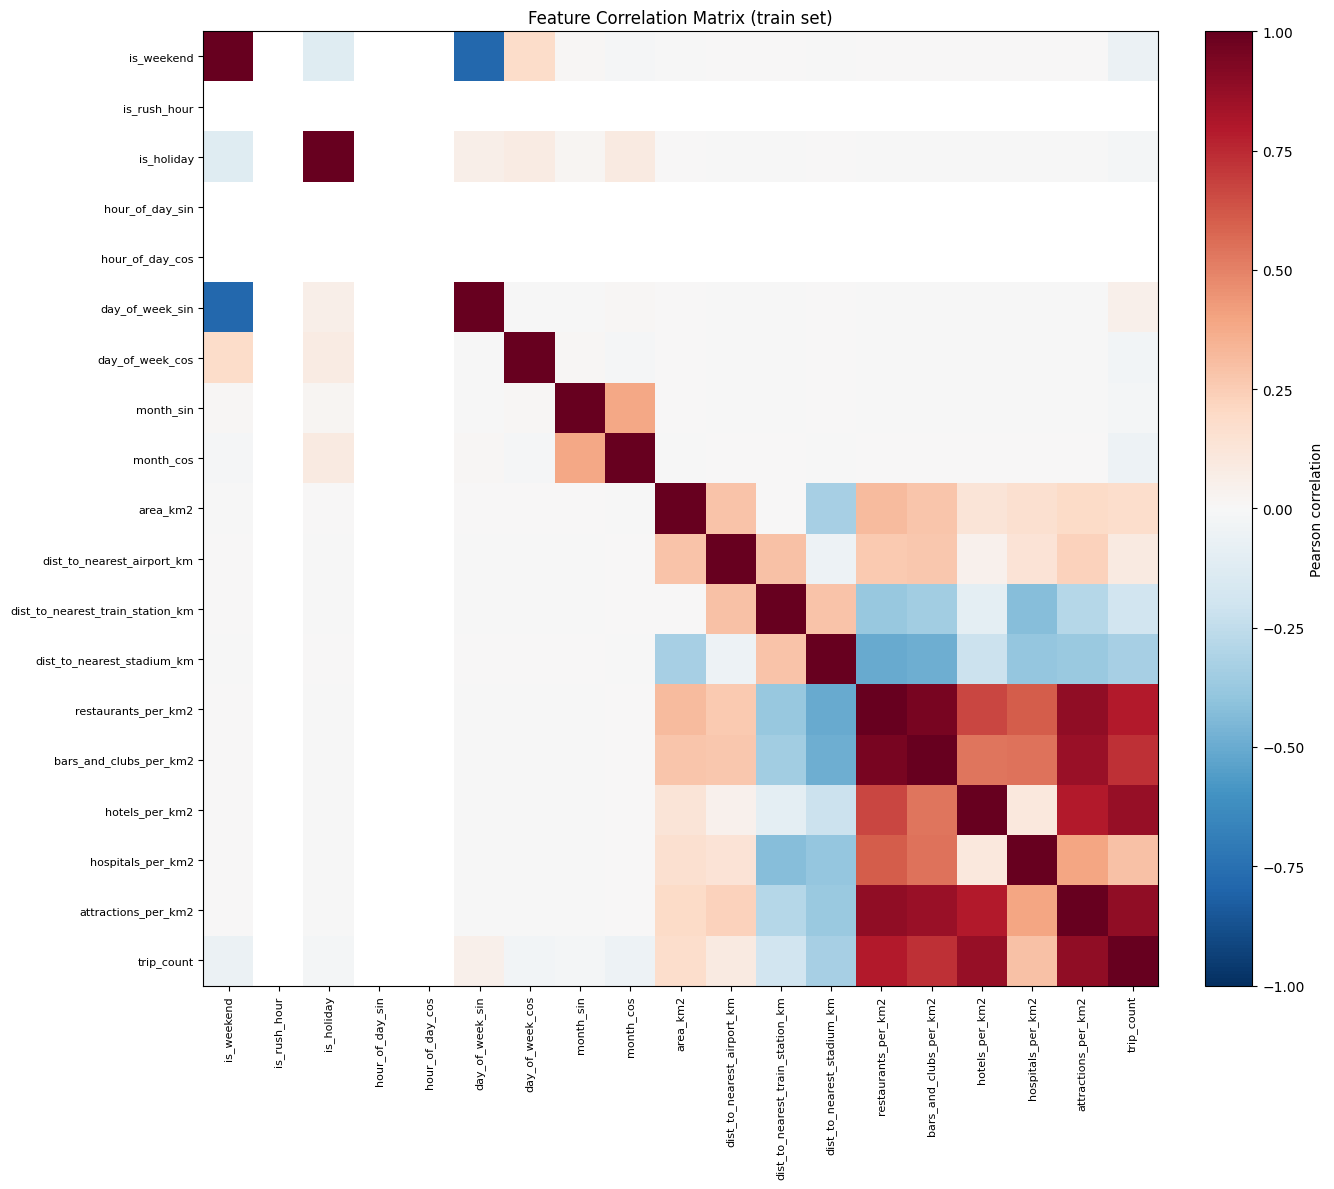

Feature pairs with |correlation| >= 0.8:
  restaurants_per_km2                 vs bars_and_clubs_per_km2               r=+0.952
  restaurants_per_km2                 vs attractions_per_km2                  r=+0.888
  attractions_per_km2                 vs trip_count                           r=+0.883
  hotels_per_km2                      vs trip_count                           r=+0.870
  bars_and_clubs_per_km2              vs attractions_per_km2                  r=+0.863


In [54]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Correlation Matrix                      #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

corr_cols   = FEATURE_COLS + [TARGET_COL]
corr_matrix = train_data[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(corr_matrix.values, cmap="RdBu_r", vmin=-1, vmax=1)

ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=90, fontsize=8)
ax.set_yticklabels(corr_cols, fontsize=8)

fig.colorbar(im, ax=ax, label="Pearson correlation", fraction=0.046, pad=0.04)
ax.set_title("Feature Correlation Matrix (train set)")
plt.tight_layout()
plt.show()

# Highly correlated feature pairs -> candidates for removal
THRESHOLD = 0.8
pairs = []
for i in range(len(corr_cols)):
    for j in range(i + 1, len(corr_cols)):
        c = corr_matrix.iloc[i, j]
        if abs(c) >= THRESHOLD:
            pairs.append((corr_cols[i], corr_cols[j], c))
pairs.sort(key=lambda x: -abs(x[2]))

print(f"Feature pairs with |correlation| >= {THRESHOLD}:")
if pairs:
    for a, b, c in pairs:
        print(f"  {a:<35s} vs {b:<35s}  r={c:+.3f}")
else:
    print("  none")

In [55]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Model-Based Feature Importance          #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=0, n_jobs=-1)
rf.fit(train_data[FEATURE_COLS], train_data[TARGET_COL])

perm = permutation_importance(
    rf, train_data[FEATURE_COLS], train_data[TARGET_COL],
    n_repeats=10, random_state=0, n_jobs=-1,
)

importance_df = pd.DataFrame({
    "feature":             FEATURE_COLS,
    "rf_importance":       rf.feature_importances_,
    "perm_importance":     perm.importances_mean,
    "perm_importance_std": perm.importances_std,
}).sort_values("perm_importance", ascending=False).reset_index(drop=True)

print(importance_df.to_string(index=False))

# Features that don't measurably help (or hurt) the model when shuffled
LOW_IMPORTANCE = importance_df.loc[importance_df["perm_importance"] <= 0, "feature"].tolist()
print(f"\nFeatures with permutation importance <= 0 (no measurable contribution, or hurting the model):")
print(f"  {LOW_IMPORTANCE if LOW_IMPORTANCE else 'none'}")

                         feature  rf_importance  perm_importance  perm_importance_std
             attractions_per_km2       0.310309         0.287030             0.003538
             restaurants_per_km2       0.281051         0.192508             0.002996
                  hotels_per_km2       0.205343         0.094695             0.001758
      dist_to_nearest_airport_km       0.037043         0.064683             0.000928
                       month_cos       0.024995         0.050267             0.003642
          bars_and_clubs_per_km2       0.072223         0.048185             0.000727
                 day_of_week_sin       0.024744         0.031167             0.002660
                      is_weekend       0.013594         0.013335             0.001717
                 day_of_week_cos       0.006205         0.007692             0.000587
dist_to_nearest_train_station_km       0.004975         0.007262             0.000103
                      is_holiday       0.004163       

## 4.2.8 Benchmark Models

Before diving into the three NN architectures, we evaluate two simple non-neural baselines on the held-out test set:

1. **Historical-mean predictor** — for each hexagon × hour-of-day pair, predict the mean `trip_count` observed in the training split. Unseen combinations fall back to the global training mean.
2. **Ridge regression** — a linear model on the same scaled feature matrix (`X_train`). Trained on log₁⁺ demand and back-transformed with `expm1` at evaluation time, matching the NN target encoding.

These numbers set the floor: any NN that cannot beat Ridge is not adding value.

Metrics match the NN evaluation cells:
- **R²** — coefficient of determination
- **MAE** — mean absolute error (in raw trip counts)
- **RMSE** — root mean squared error
- **NRMSE** — RMSE normalised by mean actual demand (scale-free)
- **MAPE** — mean absolute percentage error, computed on non-zero actuals only (zero-demand rows are excluded)

In [56]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Benchmark Models                        #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

zero_demand_count = int((y_test == 0).sum())
zero_demand_pct   = 100.0 * zero_demand_count / len(y_test)
mean_actual       = float(y_test.mean())
ss_tot            = float(np.sum((y_test - mean_actual) ** 2))

print(f"Zero-demand rows : {zero_demand_count:,} / {len(y_test):,} ({zero_demand_pct:.1f}%)")
print(f"Mean actual test demand : {mean_actual:.4f}\n")


def _eval_benchmark(label, preds):
    mae   = float(np.mean(np.abs(preds - y_test)))
    rmse  = float(np.sqrt(np.mean((preds - y_test) ** 2)))
    nrmse = rmse / mean_actual if mean_actual > 0 else float("nan")
    r2    = 1.0 - float(np.sum((preds - y_test) ** 2)) / ss_tot
    nz    = y_test > 0
    mape  = 100.0 * float(np.mean(np.abs((preds[nz] - y_test[nz]) / y_test[nz])))
    print(f"{label:<35s}  R²={r2:.4f}  MAE={mae:.4f}  RMSE={rmse:.4f}  NRMSE={nrmse:.4f}  MAPE={mape:.1f}%")
    return dict(r2=round(r2, 6), mae=round(mae, 6), rmse=round(rmse, 6), nrmse=round(nrmse, 6), mape=round(mape, 6))


# ── 1. Historical-mean predictor ───────────────────────────────────────────────
mean_table = (
    train_data.groupby(['pickup_h3_res6', 'hour_of_day'])['trip_count']
    .mean()
    .rename('pred_mean')
)
global_mean = float(train_data['trip_count'].mean())

test_lookup      = test_data[['pickup_h3_res6', 'hour_of_day']].copy()
test_lookup      = test_lookup.join(mean_table, on=['pickup_h3_res6', 'hour_of_day'])
hist_mean_preds  = test_lookup['pred_mean'].fillna(global_mean).values

bm_hist = _eval_benchmark("Historical mean (hex × hour)", hist_mean_preds)

# ── 2. Ridge regression ────────────────────────────────────────────────────────
ridge        = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)            # y_train is raw counts (Poisson) or log1p-transformed
ridge_preds  = ridge.predict(X_test) if IS_POISSON else np.expm1(ridge.predict(X_test))
ridge_preds  = np.maximum(ridge_preds, 0.0)   # clamp to non-negative

bm_ridge = _eval_benchmark("Ridge regression", ridge_preds)


Zero-demand rows : 143 / 1,807 (7.9%)
Mean actual test demand : 421.7172

Historical mean (hex × hour)         R²=0.8758  MAE=132.3384  RMSE=377.4631  NRMSE=0.8951  MAPE=67.3%
Ridge regression                     R²=0.8244  MAE=204.8672  RMSE=448.8168  NRMSE=1.0643  MAPE=196.9%


## Embed Dimension Search

Since `embed_dim` is independent of architecture depth and width, we search it once on
the baseline and fix the winner globally for all three models.

Candidates: `[8, 16, 32]` — 3 runs total (1 seed, early stopping).


In [57]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Embed Dimension Search                  #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

EMBED_CANDIDATES = [8, 16, 32]

print(f"Embed search — ARCH_BASELINE, seed={HP_SEARCH_SEEDS[0]}, patience={HP_PATIENCE}\n")
embed_results = []
for emb in EMBED_CANDIDATES:
    _, val_loss, _ = train_model(
        ARCH_BASELINE, X_train, y_train, X_val, y_val,
        hex_train, hex_val,
        seed=HP_SEARCH_SEEDS[0], device=device, verbose=False,
        lr=config.LEARNING_RATE, embed_dim=emb, patience=HP_PATIENCE,
    )
    embed_results.append((emb, val_loss))
    print(f"  embed_dim={emb:>3}  val_loss={val_loss:.4f}")

best_embed_dim = min(embed_results, key=lambda x: x[1])[0]
HEX_EMBED_DIM        = best_embed_dim
config.HEX_EMBED_DIM = best_embed_dim
print(f"\nBest embed_dim: {HEX_EMBED_DIM}  →  set as global HEX_EMBED_DIM")


Embed search — ARCH_BASELINE, seed=0, patience=5

  embed_dim=  8  val_loss=1.5466
  embed_dim= 16  val_loss=1.4255
  embed_dim= 32  val_loss=1.5740

Best embed_dim: 16  →  set as global HEX_EMBED_DIM


## 4.2.9 Baseline Model — Training

Run `ARCH_BASELINE = (2 hidden layers, 64 units)` across all seeds and report
the mean ± std validation loss.


In [58]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Baseline Model — Visualization          #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

input_dim = X_train.shape[1]
n_layers, width = ARCH_BASELINE

viz_model = DemandBaseline(input_dim, n_layers, width, N_HEX, HEX_EMBED_DIM)
x_dummy   = torch.zeros(1, input_dim)
h_dummy   = torch.zeros(1, dtype=torch.long)
summary(viz_model, input_data=(x_dummy, h_dummy), col_names=["input_size", "output_size", "num_params"], verbose=1)


Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
DemandBaseline                           [1, 18]                   [1]                       --
├─Embedding: 1-1                         [1]                       [1, 16]                   544
├─Sequential: 1-2                        [1, 34]                   [1, 1]                    --
│    └─Linear: 2-1                       [1, 34]                   [1, 64]                   2,240
│    └─ReLU: 2-2                         [1, 64]                   [1, 64]                   --
│    └─Linear: 2-3                       [1, 64]                   [1, 64]                   4,160
│    └─ReLU: 2-4                         [1, 64]                   [1, 64]                   --
│    └─Linear: 2-5                       [1, 64]                   [1, 1]                    65
│    └─Softplus: 2-6                     [1, 1]                    [1, 1]                    --
Total params: 7,009
Trainabl

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
DemandBaseline                           [1, 18]                   [1]                       --
├─Embedding: 1-1                         [1]                       [1, 16]                   544
├─Sequential: 1-2                        [1, 34]                   [1, 1]                    --
│    └─Linear: 2-1                       [1, 34]                   [1, 64]                   2,240
│    └─ReLU: 2-2                         [1, 64]                   [1, 64]                   --
│    └─Linear: 2-3                       [1, 64]                   [1, 64]                   4,160
│    └─ReLU: 2-4                         [1, 64]                   [1, 64]                   --
│    └─Linear: 2-5                       [1, 64]                   [1, 1]                    65
│    └─Softplus: 2-6                     [1, 1]                    [1, 1]                    --
Total params: 7,009
Trainabl

In [59]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Baseline Model — Training               #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

print(f"Device: {device}\n")

baseline_train_losses = []
baseline_val_losses   = []
baseline_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_BASELINE, X_train, y_train, X_val, y_val,
        hex_train, hex_val,
        lr=0.0001,
        seed=seed, device=device,
    )
    baseline_train_losses.append(train_loss)
    baseline_val_losses.append(val_loss)
    baseline_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_BASELINE, "baseline")
print(f"\n{arch_label}  train: {np.mean(baseline_train_losses):.4f} \u00b1 {np.std(baseline_train_losses):.4f}  val: {np.mean(baseline_val_losses):.4f} \u00b1 {np.std(baseline_val_losses):.4f}")

run_results = evaluate_models(
    ARCH_BASELINE, baseline_models, baseline_train_losses, baseline_val_losses,
    X_test, y_test, hex_test,
    device=device,
    show_weight_stats=True,
)

Device: cpu

Epoch   1/200
  loss: 3.2763  val_loss: 3.1757 ✓
Epoch   2/200
  loss: 3.2611  val_loss: 3.1405 ✓
Epoch   3/200
  loss: 3.2005  val_loss: 3.0980 ✓
Epoch   4/200
  loss: 3.1603  val_loss: 3.0528 ✓
Epoch   5/200
  loss: 3.1033  val_loss: 3.0067 ✓
Epoch   6/200
  loss: 3.0915  val_loss: 2.9602 ✓
Epoch   7/200
  loss: 3.0191  val_loss: 2.9127 ✓
Epoch   8/200
  loss: 2.9536  val_loss: 2.8659 ✓
Epoch   9/200
  loss: 2.9128  val_loss: 2.8201 ✓
Epoch  10/200
  loss: 2.8410  val_loss: 2.7755 ✓
Epoch  11/200
  loss: 2.8140  val_loss: 2.7326 ✓
Epoch  12/200
  loss: 2.7761  val_loss: 2.6897 ✓
Epoch  13/200
  loss: 2.7334  val_loss: 2.6470 ✓
Epoch  14/200
  loss: 2.6803  val_loss: 2.6044 ✓
Epoch  15/200
  loss: 2.6287  val_loss: 2.5624 ✓
Epoch  16/200
  loss: 2.5817  val_loss: 2.5201 ✓
Epoch  17/200
  loss: 2.5466  val_loss: 2.4785 ✓
Epoch  18/200
  loss: 2.5008  val_loss: 2.4369 ✓
Epoch  19/200
  loss: 2.4614  val_loss: 2.3947 ✓
Epoch  20/200
  loss: 2.4197  val_loss: 2.3520 ✓
Epoch  

### 4.2.9 Baseline Model — Evaluation

Evaluate on the held-out **test set** using the best-checkpoint model from each
seed, then report mean ± std across seeds.

Metrics:
- **Zero-demand rows** — share of test rows with `trip_count = 0` (context for inflated R²)
- **Mean Actual Test Demand** — average true trip count in the test set
- **R²** — coefficient of determination (share of variance explained)
- **MAE** — mean absolute error (interpretable in trip counts)
- **RMSE** — root mean squared error (penalises large misses more)
- **NRMSE** — RMSE normalised by mean actual demand (scale-free)
- **MAPE** — mean absolute percentage error, computed on non-zero actuals only (zero-demand rows are excluded)

In [60]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Baseline Model — Evaluation             #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

run_results = evaluate_models(
    ARCH_BASELINE, baseline_models, baseline_train_losses, baseline_val_losses,
    X_test, y_test, hex_test,
    device=device,
    show_weight_stats=True,
)

Zero-demand rows: 143 / 1,807 (7.9%)
Mean actual test demand : 421.7172  (min=0.0000, max=8320.0000)

  seed=0 layer weight stats:
    hex_embed.weight  shape=(34, 16)      max|w|=0.0437  mean|w|=0.0114  norm=0.3372
    net.0.weight    shape=(64, 34)      max|w|=0.8531  mean|w|=0.1919  norm=11.3020
    net.2.weight    shape=(64, 64)      max|w|=0.6731  mean|w|=0.1441  norm=11.5309
    net.4.weight    shape=(1, 64)       max|w|=0.5737  mean|w|=0.1686  norm=1.7004
  seed=0  R²=0.7960  MAE=214.3455  NRMSE=1.1471  MAPE=373.5%  | log  R²=0.4072  MAE=1.2249  NRMSE=0.4208  | zeros 0/143  false=0  | pred min=1.5 max=6050.2

--- original scale ---
Baseline  R²    : 0.7960 ± 0.0000
Baseline  MAE   : 214.3455 ± 0.0000
Baseline  RMSE  : 483.7662 ± 0.0000
Baseline  NRMSE : 1.1471 ± 0.0000
Baseline  MAPE  : 373.49% ± 0.00%  (non-zero actuals only)

--- log1p scale ---
Baseline  R²    : 0.4072 ± 0.0000
Baseline  MAE   : 1.2249 ± 0.0000
Baseline  RMSE  : 1.6984 ± 0.0000
Baseline  NRMSE : 0.4208 ± 0.00

In [61]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

results_df = save_results(run_results)

Appended 1 rows to data/results/nn_results_hex_6_24h.csv (27 columns)
          timestamp training_loss    model  n_layers  width  learning_rate  weight_decay  batch_size  seed  val_loss  zero_demand_count  mean_actual    r2        mae       rmse    nrmse   r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min    pred_max  overfitting_measures hidden_activation      mape
2026-07-19T21:21:11           mae baseline         2     64        0.00005           0.0        1024     0  1.239842                143   421.717211 0.796 214.345482 483.766183 1.147134 0.407196 1.224881   1.69844   0.420807             0           0  1.452828 6050.175293                   NaN              relu 373.48714


## 4.2.10 Hyperparameter Search — Baseline Model

Two-step coarse→fine grid search (Optuna `GridSampler`, both steps exhaustive):

1. **Decade grid** — `HP_LR_DECADES` × `HP_WD_DECADES`, one representative value
   per order of magnitude, locates the best decade for each hyperparameter.
2. **Fine grid** — `HP_FINE_STEPS` scaled into the winning decade (e.g. decade
   1e-3 → 2e-3, 4e-3, 5e-3, 6e-3, 8e-3), evaluated only inside the decades that
   won step 1.

Only rough orders of magnitude need to be chosen upfront — the fine candidates
are derived from the step-1 result. Each trial trains one model per seed in
`HP_SEARCH_SEEDS` and is scored by the mean validation loss; the median pruner
stops clearly bad combinations early. The final best combination is stored in
`BEST_HP[ARCH_BASELINE]`.


In [62]:
run_hp_search_2step(
    ARCH_BASELINE,
    X_train, y_train, X_val, y_val,
    hex_train, hex_val,
    device=device,
)

=== Step 1/2 — decade grid (baseline) ===

HP Search — baseline  |  grid 12×4 = 48 combos  |  seeds=(0,)  |  patience=5

   #          lr          wd    mean val  state
--------------------------------------------------
   1    5.00e-03    5.00e-04      0.3070  complete
   2    5.00e-05    0.00e+00      1.4255  complete
   3    2.00e-03    5.00e-03      0.3176  complete
   4    5.00e-03    5.00e-03      0.3049  complete
   5    8.00e-03    0.00e+00      0.3193  complete
   6    2.00e-02    5.00e-04      0.3109  complete
   7    8.00e-03    5.00e-03      0.3104  complete
   8    5.00e-02    0.00e+00      0.2935  complete
   9    5.00e-05    5.00e-02      3.0791  pruned
  10    8.00e-05    5.00e-03      3.0072  pruned
  11    8.00e-05    5.00e-02      3.0101  pruned
  12    5.00e-03    5.00e-02      1.2111  pruned
  13    8.00e-03    5.00e-04      0.3191  complete
  14    2.00e-03    5.00e-02      1.4564  pruned
  15    8.00e-02    5.00e-02      0.3711  complete
  16    2.00e-05    5.00e

{'lr': 0.02, 'weight_decay': 0.005}

### 4.2.10 Tuned Baseline — Training

Re-train the baseline architecture with the best hyperparameters found above,
across all `SEEDS` for a stable mean ± std estimate.


In [63]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Baseline — Training              #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

hp = BEST_HP[ARCH_BASELINE]
print(f"Best HP: {hp}\n")

tuned_train_losses = []
tuned_val_losses   = []
tuned_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_BASELINE, X_train, y_train, X_val, y_val,
        hex_train, hex_val,
        seed=seed, device=device,
        lr=hp["lr"],
        weight_decay=hp.get("weight_decay", 0.0),
    )
    tuned_train_losses.append(train_loss)
    tuned_val_losses.append(val_loss)
    tuned_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_BASELINE, "baseline")
print(f"\n{arch_label}  train: {np.mean(tuned_train_losses):.4f} \u00b1 {np.std(tuned_train_losses):.4f}  val: {np.mean(tuned_val_losses):.4f} \u00b1 {np.std(tuned_val_losses):.4f}")

Best HP: {'lr': 0.02, 'weight_decay': 0.005}

Epoch   1/200
  loss: 2.5501  val_loss: 2.1792 ✓
Epoch   2/200
  loss: 1.6339  val_loss: 1.3684 ✓
Epoch   3/200
  loss: 1.2974  val_loss: 1.2272 ✓
Epoch   4/200
  loss: 1.0621  val_loss: 1.0296 ✓
Epoch   5/200
  loss: 0.8898  val_loss: 0.9351 ✓
Epoch   6/200
  loss: 0.7087  val_loss: 0.7810 ✓
Epoch   7/200
  loss: 0.5864  val_loss: 0.6741 ✓
Epoch   8/200
  loss: 0.4783  val_loss: 0.5699 ✓
Epoch   9/200
  loss: 0.4053  val_loss: 0.5061 ✓
Epoch  10/200
  loss: 0.3487  val_loss: 0.4471 ✓
Epoch  11/200
  loss: 0.3018  val_loss: 0.4358 ✓
Epoch  12/200
  loss: 0.2663  val_loss: 0.4006 ✓
Epoch  13/200
  loss: 0.2431  val_loss: 0.3859 ✓
Epoch  14/200
  loss: 0.2294  val_loss: 0.3502 ✓
Epoch  15/200
  loss: 0.2201  val_loss: 0.3375 ✓
Epoch  16/200
  loss: 0.2119  val_loss: 0.3438  (no improvement 1/10)
Epoch  17/200
  loss: 0.2020  val_loss: 0.3440  (no improvement 2/10)
Epoch  18/200
  loss: 0.1911  val_loss: 0.3185 ✓
Epoch  19/200
  loss: 0.1836  

### 4.2.10 Tuned Baseline — Evaluation

Evaluate on the held-out **test set** and compare against the untuned baseline.


In [64]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Baseline — Evaluation             #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

run_results = evaluate_models(
    ARCH_BASELINE, tuned_models, tuned_train_losses, tuned_val_losses,
    X_test, y_test, hex_test,
    device=device, label="Tuned Baseline", model_name="baseline_tuned",
    hp=BEST_HP[ARCH_BASELINE],
)

Zero-demand rows: 143 / 1,807 (7.9%)
Mean actual test demand : 421.7172  (min=0.0000, max=8320.0000)

  seed=0  R²=0.9170  MAE=104.8457  NRMSE=0.7317  MAPE=48.6%  | log  R²=0.9608  MAE=0.3424  NRMSE=0.1082  | zeros 103/143  false=7  | pred min=0.1 max=6709.7

--- original scale ---
Tuned Baseline  R²    : 0.9170 ± 0.0000
Tuned Baseline  MAE   : 104.8457 ± 0.0000
Tuned Baseline  RMSE  : 308.5882 ± 0.0000
Tuned Baseline  NRMSE : 0.7317 ± 0.0000
Tuned Baseline  MAPE  : 48.59% ± 0.00%  (non-zero actuals only)

--- log1p scale ---
Tuned Baseline  R²    : 0.9608 ± 0.0000
Tuned Baseline  MAE   : 0.3424 ± 0.0000
Tuned Baseline  RMSE  : 0.4368 ± 0.0000
Tuned Baseline  NRMSE : 0.1082 ± 0.0000

--- zero-demand ---
Tuned Baseline  Correct-zero : 103.0 ± 0.0  (out of 143)
Tuned Baseline  False-zero   : 7.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range (raw scale) ---
Tuned Baseline  Pred min : 0.0673 ± 0.0000
Tuned Baseline  Pred max : 6709.7451 ± 0.0000  (actual max: 8320.0000)

--- o

In [65]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

results_df = save_results(run_results)

Appended 1 rows to data/results/nn_results_hex_6_24h.csv (27 columns)
          timestamp training_loss          model  n_layers  width  learning_rate  weight_decay  batch_size  seed  val_loss  zero_demand_count  mean_actual       r2        mae       rmse    nrmse  r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min    pred_max  overfitting_measures hidden_activation     mape
2026-07-19T21:21:47           mae baseline_tuned         2     64           0.02         0.005        1024     0  0.286948                143   421.717211 0.916992 104.845701 308.588172 0.731742  0.9608  0.34241  0.436756   0.108211           103           7  0.067311 6709.745117                   NaN              relu 48.58528


## 4.2.11 Deeper Model — Training

Run `ARCH_DEEPER = (4 hidden layers, 64 units)` across all seeds.
Width is fixed; depth doubles relative to the baseline.


In [66]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Deeper   Model — Training              #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

deeper_train_losses = []
deeper_val_losses   = []
deeper_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_DEEPER, X_train, y_train, X_val, y_val,
        hex_train, hex_val,
        seed=seed, device=device,
    )
    deeper_train_losses.append(train_loss)
    deeper_val_losses.append(val_loss)
    deeper_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_DEEPER, "deep")
print(f"\n{arch_label}  train: {np.mean(deeper_train_losses):.4f} \u00b1 {np.std(deeper_train_losses):.4f}  val: {np.mean(deeper_val_losses):.4f} \u00b1 {np.std(deeper_val_losses):.4f}")

Epoch   1/200
  loss: 3.6299  val_loss: 3.5263 ✓
Epoch   2/200
  loss: 3.6217  val_loss: 3.4979 ✓
Epoch   3/200
  loss: 3.5809  val_loss: 3.4621 ✓
Epoch   4/200
  loss: 3.5402  val_loss: 3.4222 ✓
Epoch   5/200
  loss: 3.5037  val_loss: 3.3798 ✓
Epoch   6/200
  loss: 3.4662  val_loss: 3.3338 ✓
Epoch   7/200
  loss: 3.4331  val_loss: 3.2844 ✓
Epoch   8/200
  loss: 3.4039  val_loss: 3.2306 ✓
Epoch   9/200
  loss: 3.3372  val_loss: 3.1730 ✓
Epoch  10/200
  loss: 3.2954  val_loss: 3.1103 ✓
Epoch  11/200
  loss: 3.2086  val_loss: 3.0420 ✓
Epoch  12/200
  loss: 3.1334  val_loss: 2.9686 ✓
Epoch  13/200
  loss: 3.0770  val_loss: 2.8907 ✓
Epoch  14/200
  loss: 2.9947  val_loss: 2.8065 ✓
Epoch  15/200
  loss: 2.9061  val_loss: 2.7144 ✓
Epoch  16/200
  loss: 2.8299  val_loss: 2.6169 ✓
Epoch  17/200
  loss: 2.7290  val_loss: 2.5165 ✓
Epoch  18/200
  loss: 2.6030  val_loss: 2.4154 ✓
Epoch  19/200
  loss: 2.5144  val_loss: 2.3165 ✓
Epoch  20/200
  loss: 2.4057  val_loss: 2.2257 ✓
Epoch  21/200
  loss

### 4.2.11 Deeper Model — Evaluation

Evaluate on the held-out **test set** using the best-checkpoint model from each
seed, then report mean ± std across seeds.

Metrics:
- **Zero-demand rows** — share of test rows with `trip_count = 0` (context for inflated R²)
- **Mean Actual Test Demand** — average true trip count in the test set
- **R²** — coefficient of determination (share of variance explained)
- **MAE** — mean absolute error (interpretable in trip counts)
- **RMSE** — root mean squared error (penalises large misses more)
- **NRMSE** — RMSE normalised by mean actual demand (scale-free)
- **MAPE** — mean absolute percentage error, computed on non-zero actuals only (zero-demand rows are excluded)

In [67]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Deeper   Model — Evaluation             #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

run_results = evaluate_models(
    ARCH_DEEPER, deeper_models, deeper_train_losses, deeper_val_losses,
    X_test, y_test, hex_test,
    device=device,
)

Zero-demand rows: 143 / 1,807 (7.9%)
Mean actual test demand : 421.7172  (min=0.0000, max=8320.0000)

  seed=0  R²=0.7325  MAE=221.6827  NRMSE=1.3137  MAPE=347.6%  | log  R²=0.4708  MAE=1.1535  NRMSE=0.3976  | zeros 0/143  false=0  | pred min=2.4 max=7815.1

--- original scale ---
Deep  R²    : 0.7325 ± 0.0000
Deep  MAE   : 221.6827 ± 0.0000
Deep  RMSE  : 554.0012 ± 0.0000
Deep  NRMSE : 1.3137 ± 0.0000
Deep  MAPE  : 347.65% ± 0.00%  (non-zero actuals only)

--- log1p scale ---
Deep  R²    : 0.4708 ± 0.0000
Deep  MAE   : 1.1535 ± 0.0000
Deep  RMSE  : 1.6047 ± 0.0000
Deep  NRMSE : 0.3976 ± 0.0000

--- zero-demand ---
Deep  Correct-zero : 0.0 ± 0.0  (out of 143)
Deep  False-zero   : 0.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range (raw scale) ---
Deep  Pred min : 2.3643 ± 0.0000
Deep  Pred max : 7815.0747 ± 0.0000  (actual max: 8320.0000)

--- overfitting check (MSE, log1p scale) ---
               train       val      test
  seed=0       0.9737    1.1075    2.5751


In [68]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

results_df = save_results(run_results)

Appended 1 rows to data/results/nn_results_hex_6_24h.csv (27 columns)
          timestamp training_loss model  n_layers  width  learning_rate  weight_decay  batch_size  seed  val_loss  zero_demand_count  mean_actual       r2        mae       rmse    nrmse   r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min    pred_max  overfitting_measures hidden_activation       mape
2026-07-19T21:21:52           mae  deep         8     64        0.00005           0.0        1024     0  1.107506                143   421.717211 0.732465 221.682653 554.001191 1.313679 0.470811 1.153539  1.604723   0.397587             0           0  2.364301 7815.074707                   NaN              relu 347.645851


## 4.2.12 Hyperparameter Search — Deeper Model

Two-step coarse→fine grid search (Optuna `GridSampler`, both steps exhaustive):

1. **Decade grid** — `HP_LR_DECADES` × `HP_WD_DECADES`, one representative value
   per order of magnitude, locates the best decade for each hyperparameter.
2. **Fine grid** — `HP_FINE_STEPS` scaled into the winning decade (e.g. decade
   1e-3 → 2e-3, 4e-3, 5e-3, 6e-3, 8e-3), evaluated only inside the decades that
   won step 1.

Only rough orders of magnitude need to be chosen upfront — the fine candidates
are derived from the step-1 result. Each trial trains one model per seed in
`HP_SEARCH_SEEDS` and is scored by the mean validation loss; the median pruner
stops clearly bad combinations early. The final best combination is stored in
`BEST_HP[ARCH_DEEPER]`.


In [69]:
run_hp_search_2step(
    ARCH_DEEPER,
    X_train, y_train, X_val, y_val,
    hex_train, hex_val,
    device=device,
)

=== Step 1/2 — decade grid (deep) ===

HP Search — deep  |  grid 12×4 = 48 combos  |  seeds=(0,)  |  patience=5

   #          lr          wd    mean val  state
--------------------------------------------------
   1    5.00e-03    5.00e-04      0.3425  complete
   2    5.00e-05    0.00e+00      1.1075  complete
   3    2.00e-03    5.00e-03      0.3621  complete
   4    5.00e-03    5.00e-03      0.3415  complete
   5    8.00e-03    0.00e+00      0.3362  complete
   6    2.00e-02    5.00e-04      0.3715  complete
   7    8.00e-03    5.00e-03      0.3145  complete
   8    5.00e-02    0.00e+00      0.2662  complete
   9    5.00e-05    5.00e-02      3.3376  pruned
  10    8.00e-05    5.00e-03      3.1795  pruned
  11    8.00e-05    5.00e-02      3.1882  pruned
  12    5.00e-03    5.00e-02      1.0356  pruned
  13    8.00e-03    5.00e-04      0.2940  complete
  14    2.00e-03    5.00e-02      1.2964  pruned
  15    8.00e-02    5.00e-02      1.7970  pruned
  16    2.00e-05    5.00e-03      3

{'lr': 0.06, 'weight_decay': 0.004}

### 4.2.12 Tuned Deeper — Training

Re-train the deeper architecture with the best hyperparameters found above,
across all `SEEDS` for a stable mean ± std estimate.

In [70]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Deeper — Training                #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

hp = BEST_HP[ARCH_DEEPER]
print(f"Best HP: {hp}\n")

tuned_deeper_train_losses = []
tuned_deeper_val_losses   = []
tuned_deeper_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_DEEPER, X_train, y_train, X_val, y_val,
        hex_train, hex_val,
        seed=seed, device=device,
        lr=hp["lr"],
        weight_decay=hp.get("weight_decay", 0.0),
    )
    tuned_deeper_train_losses.append(train_loss)
    tuned_deeper_val_losses.append(val_loss)
    tuned_deeper_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_DEEPER, "deep")
print(f"\n{arch_label}  train: {np.mean(tuned_deeper_train_losses):.4f} ± {np.std(tuned_deeper_train_losses):.4f}  val: {np.mean(tuned_deeper_val_losses):.4f} ± {np.std(tuned_deeper_val_losses):.4f}")

Best HP: {'lr': 0.06, 'weight_decay': 0.004}

Epoch   1/200
  loss: 2.6616  val_loss: 2.1161 ✓
Epoch   2/200
  loss: 2.1138  val_loss: 2.1966  (no improvement 1/10)
Epoch   3/200
  loss: 1.6293  val_loss: 1.4733 ✓
Epoch   4/200
  loss: 1.2784  val_loss: 1.2861 ✓
Epoch   5/200
  loss: 0.9954  val_loss: 0.8757 ✓
Epoch   6/200
  loss: 0.6706  val_loss: 0.6430 ✓
Epoch   7/200
  loss: 0.5282  val_loss: 0.6376 ✓
Epoch   8/200
  loss: 0.6060  val_loss: 0.4375 ✓
Epoch   9/200
  loss: 0.4757  val_loss: 0.3942 ✓
Epoch  10/200
  loss: 0.4048  val_loss: 0.5141  (no improvement 1/10)
Epoch  11/200
  loss: 0.3129  val_loss: 0.3493 ✓
Epoch  12/200
  loss: 0.4014  val_loss: 0.8239  (no improvement 1/10)
Epoch  13/200
  loss: 0.5639  val_loss: 0.7750  (no improvement 2/10)
Epoch  14/200
  loss: 0.5979  val_loss: 0.5584  (no improvement 3/10)
Epoch  15/200
  loss: 0.3261  val_loss: 0.4696  (no improvement 4/10)
Epoch  16/200
  loss: 0.2765  val_loss: 0.2933 ✓
Epoch  17/200
  loss: 0.1928  val_loss: 0.33

### 4.2.12 Tuned Deeper — Evaluation

Evaluate on the held-out **test set** and compare against the untuned deeper model.

In [71]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Deeper — Evaluation               #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

run_results = evaluate_models(
    ARCH_DEEPER, tuned_deeper_models, tuned_deeper_train_losses, tuned_deeper_val_losses,
    X_test, y_test, hex_test,
    device=device, label="Tuned Deeper", model_name="deep_tuned",
    hp=BEST_HP[ARCH_DEEPER],
)

Zero-demand rows: 143 / 1,807 (7.9%)
Mean actual test demand : 421.7172  (min=0.0000, max=8320.0000)

  seed=0  R²=0.8943  MAE=116.1083  NRMSE=0.8256  MAPE=43.0%  | log  R²=0.9656  MAE=0.3134  NRMSE=0.1014  | zeros 103/143  false=7  | pred min=0.0 max=5618.3

--- original scale ---
Tuned Deeper  R²    : 0.8943 ± 0.0000
Tuned Deeper  MAE   : 116.1083 ± 0.0000
Tuned Deeper  RMSE  : 348.1623 ± 0.0000
Tuned Deeper  NRMSE : 0.8256 ± 0.0000
Tuned Deeper  MAPE  : 43.02% ± 0.00%  (non-zero actuals only)

--- log1p scale ---
Tuned Deeper  R²    : 0.9656 ± 0.0000
Tuned Deeper  MAE   : 0.3134 ± 0.0000
Tuned Deeper  RMSE  : 0.4094 ± 0.0000
Tuned Deeper  NRMSE : 0.1014 ± 0.0000

--- zero-demand ---
Tuned Deeper  Correct-zero : 103.0 ± 0.0  (out of 143)
Tuned Deeper  False-zero   : 7.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range (raw scale) ---
Tuned Deeper  Pred min : 0.0093 ± 0.0000
Tuned Deeper  Pred max : 5618.2690 ± 0.0000  (actual max: 8320.0000)

--- overfitting check (MSE, log

In [72]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

results_df = save_results(run_results)

Appended 1 rows to data/results/nn_results_hex_6_24h.csv (27 columns)
          timestamp training_loss      model  n_layers  width  learning_rate  weight_decay  batch_size  seed  val_loss  zero_demand_count  mean_actual       r2      mae       rmse    nrmse   r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min    pred_max  overfitting_measures hidden_activation      mape
2026-07-19T21:22:34           mae deep_tuned         8     64           0.06         0.004        1024     0  0.250151                143   421.717211 0.894337 116.1083 348.162267 0.825582 0.965563 0.313408  0.409365   0.101424           103           7  0.009334 5618.269043                   NaN              relu 43.018643


### 4.2.12 Wider Model — Training

Run `ARCH_WIDER = (2 hidden layers, 128 units)` across all seeds.
Depth is fixed; width doubles relative to the baseline.


In [73]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Wider    Model — Training              #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

wider_train_losses = []
wider_val_losses   = []
wider_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_WIDER, X_train, y_train, X_val, y_val,
        hex_train, hex_val,
        seed=seed, device=device,
    )
    wider_train_losses.append(train_loss)
    wider_val_losses.append(val_loss)
    wider_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_WIDER, "wide")
print(f"\n{arch_label}  train: {np.mean(wider_train_losses):.4f} \u00b1 {np.std(wider_train_losses):.4f}  val: {np.mean(wider_val_losses):.4f} \u00b1 {np.std(wider_val_losses):.4f}")

Epoch   1/200
  loss: 3.9404  val_loss: 3.8209 ✓
Epoch   2/200
  loss: 3.9311  val_loss: 3.7955 ✓
Epoch   3/200
  loss: 3.8982  val_loss: 3.7627 ✓
Epoch   4/200
  loss: 3.8555  val_loss: 3.7246 ✓
Epoch   5/200
  loss: 3.8390  val_loss: 3.6816 ✓
Epoch   6/200
  loss: 3.8073  val_loss: 3.6347 ✓
Epoch   7/200
  loss: 3.7681  val_loss: 3.5830 ✓
Epoch   8/200
  loss: 3.7096  val_loss: 3.5265 ✓
Epoch   9/200
  loss: 3.6767  val_loss: 3.4660 ✓
Epoch  10/200
  loss: 3.6064  val_loss: 3.4010 ✓
Epoch  11/200
  loss: 3.5495  val_loss: 3.3317 ✓
Epoch  12/200
  loss: 3.4910  val_loss: 3.2582 ✓
Epoch  13/200
  loss: 3.4162  val_loss: 3.1809 ✓
Epoch  14/200
  loss: 3.3515  val_loss: 3.0996 ✓
Epoch  15/200
  loss: 3.2811  val_loss: 3.0140 ✓
Epoch  16/200
  loss: 3.2132  val_loss: 2.9256 ✓
Epoch  17/200
  loss: 3.0996  val_loss: 2.8356 ✓
Epoch  18/200
  loss: 3.0496  val_loss: 2.7442 ✓
Epoch  19/200
  loss: 2.9684  val_loss: 2.6514 ✓
Epoch  20/200
  loss: 2.8693  val_loss: 2.5589 ✓
Epoch  21/200
  loss

### 4.2.12 Wider Model — Evaluation

Evaluate on the held-out **test set** using the best-checkpoint model from each
seed, then report mean ± std across seeds.

Metrics:
- **Zero-demand rows** — share of test rows with `trip_count = 0` (context for inflated R²)
- **Mean Actual Test Demand** — average true trip count in the test set
- **R²** — coefficient of determination (share of variance explained)
- **MAE** — mean absolute error (interpretable in trip counts)
- **RMSE** — root mean squared error (penalises large misses more)
- **NRMSE** — RMSE normalised by mean actual demand (scale-free)
- **MAPE** — mean absolute percentage error, computed on non-zero actuals only (zero-demand rows are excluded)

In [74]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Wider    Model — Evaluation             #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

run_results = evaluate_models(
    ARCH_WIDER, wider_models, wider_train_losses, wider_val_losses,
    X_test, y_test, hex_test,
    device=device,
)

Zero-demand rows: 143 / 1,807 (7.9%)
Mean actual test demand : 421.7172  (min=0.0000, max=8320.0000)

  seed=0  R²=0.8559  MAE=180.0639  NRMSE=0.9642  MAPE=341.8%  | log  R²=0.4282  MAE=1.1234  NRMSE=0.4133  | zeros 0/143  false=0  | pred min=1.0 max=6365.1

--- original scale ---
Wide  R²    : 0.8559 ± 0.0000
Wide  MAE   : 180.0639 ± 0.0000
Wide  RMSE  : 406.6197 ± 0.0000
Wide  NRMSE : 0.9642 ± 0.0000
Wide  MAPE  : 341.82% ± 0.00%  (non-zero actuals only)

--- log1p scale ---
Wide  R²    : 0.4282 ± 0.0000
Wide  MAE   : 1.1234 ± 0.0000
Wide  RMSE  : 1.6681 ± 0.0000
Wide  NRMSE : 0.4133 ± 0.0000

--- zero-demand ---
Wide  Correct-zero : 0.0 ± 0.0  (out of 143)
Wide  False-zero   : 0.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range (raw scale) ---
Wide  Pred min : 1.0297 ± 0.0000
Wide  Pred max : 6365.0942 ± 0.0000  (actual max: 8320.0000)

--- overfitting check (MSE, log1p scale) ---
               train       val      test
  seed=0       1.0842    1.1244    2.7826


In [75]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

results_df = save_results(run_results)

Appended 1 rows to data/results/nn_results_hex_6_24h.csv (27 columns)
          timestamp training_loss model  n_layers  width  learning_rate  weight_decay  batch_size  seed  val_loss  zero_demand_count  mean_actual       r2        mae       rmse  nrmse   r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min    pred_max  overfitting_measures hidden_activation       mape
2026-07-19T21:22:39           mae  wide         2    256        0.00005           0.0        1024     0  1.124391                143   421.717211 0.855876 180.063941 406.619744 0.9642 0.428183 1.123418  1.668105   0.413291             0           0  1.029676 6365.094238                   NaN              relu 341.816186


### 4.2.12 Hyperparameter Search — Wider Model

Two-step coarse→fine grid search (Optuna `GridSampler`, both steps exhaustive):

1. **Decade grid** — `HP_LR_DECADES` × `HP_WD_DECADES`, one representative value
   per order of magnitude, locates the best decade for each hyperparameter.
2. **Fine grid** — `HP_FINE_STEPS` scaled into the winning decade (e.g. decade
   1e-3 → 2e-3, 4e-3, 5e-3, 6e-3, 8e-3), evaluated only inside the decades that
   won step 1.

Only rough orders of magnitude need to be chosen upfront — the fine candidates
are derived from the step-1 result. Each trial trains one model per seed in
`HP_SEARCH_SEEDS` and is scored by the mean validation loss; the median pruner
stops clearly bad combinations early. The final best combination is stored in
`BEST_HP[ARCH_WIDER]`.


In [76]:
run_hp_search_2step(
    ARCH_WIDER,
    X_train, y_train, X_val, y_val,
    hex_train, hex_val,
    device=device,
)

=== Step 1/2 — decade grid (wide) ===

HP Search — wide  |  grid 12×4 = 48 combos  |  seeds=(0,)  |  patience=5

   #          lr          wd    mean val  state
--------------------------------------------------
   1    5.00e-03    5.00e-04      0.2904  complete
   2    5.00e-05    0.00e+00      1.1244  complete
   3    2.00e-03    5.00e-03      0.2990  complete
   4    5.00e-03    5.00e-03      0.2927  complete
   5    8.00e-03    0.00e+00      0.2750  complete
   6    2.00e-02    5.00e-04      0.2529  complete
   7    8.00e-03    5.00e-03      0.2671  complete
   8    5.00e-02    0.00e+00      0.2597  complete
   9    5.00e-05    5.00e-02      3.6348  pruned
  10    8.00e-05    5.00e-03      3.4736  pruned
  11    8.00e-05    5.00e-02      3.4745  pruned
  12    5.00e-03    5.00e-02      1.0375  pruned
  13    8.00e-03    5.00e-04      0.2807  complete
  14    2.00e-03    5.00e-02      1.2041  pruned
  15    8.00e-02    5.00e-02      0.3609  complete
  16    2.00e-05    5.00e-03     

{'lr': 0.04, 'weight_decay': 0.006}

In [77]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Wider — Training                 #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

hp = BEST_HP[ARCH_WIDER]
print(f"Best HP: {hp}\n")

tuned_wider_train_losses = []
tuned_wider_val_losses   = []
tuned_wider_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_WIDER, X_train, y_train, X_val, y_val,
        hex_train, hex_val,
        seed=seed, device=device,
        lr=hp["lr"],
        weight_decay=hp.get("weight_decay", 0.0),
    )
    tuned_wider_train_losses.append(train_loss)
    tuned_wider_val_losses.append(val_loss)
    tuned_wider_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_WIDER, "wide")
print(f"\n{arch_label}  train: {np.mean(tuned_wider_train_losses):.4f} \u00b1 {np.std(tuned_wider_train_losses):.4f}  val: {np.mean(tuned_wider_val_losses):.4f} \u00b1 {np.std(tuned_wider_val_losses):.4f}")

Best HP: {'lr': 0.04, 'weight_decay': 0.006}

Epoch   1/200
  loss: 2.6353  val_loss: 1.2906 ✓
Epoch   2/200
  loss: 1.4452  val_loss: 1.0758 ✓
Epoch   3/200
  loss: 1.0211  val_loss: 0.9817 ✓
Epoch   4/200
  loss: 0.7131  val_loss: 0.7523 ✓
Epoch   5/200
  loss: 0.5310  val_loss: 0.5028 ✓
Epoch   6/200
  loss: 0.3530  val_loss: 0.3461 ✓
Epoch   7/200
  loss: 0.2973  val_loss: 0.3456 ✓
Epoch   8/200
  loss: 0.2466  val_loss: 0.3833  (no improvement 1/10)
Epoch   9/200
  loss: 0.2696  val_loss: 0.3003 ✓
Epoch  10/200
  loss: 0.2747  val_loss: 0.4527  (no improvement 1/10)
Epoch  11/200
  loss: 0.3165  val_loss: 0.3810  (no improvement 2/10)
Epoch  12/200
  loss: 0.2737  val_loss: 0.3055  (no improvement 3/10)
Epoch  13/200
  loss: 0.2089  val_loss: 0.3216  (no improvement 4/10)
Epoch  14/200
  loss: 0.1805  val_loss: 0.2918 ✓
Epoch  15/200
  loss: 0.1996  val_loss: 0.3955  (no improvement 1/10)
Epoch  16/200
  loss: 0.2522  val_loss: 0.3395  (no improvement 2/10)
Epoch  17/200
  loss: 0

### 4.2.12 Tuned Wider — Evaluation

Evaluate on the held-out **test set** and compare against the untuned wider model.

In [78]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Wider — Evaluation                #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

run_results = evaluate_models(
    ARCH_WIDER, tuned_wider_models, tuned_wider_train_losses, tuned_wider_val_losses,
    X_test, y_test, hex_test,
    device=device, label="Tuned Wider", model_name="wider_tuned",
    hp=BEST_HP[ARCH_WIDER],
)

Zero-demand rows: 143 / 1,807 (7.9%)
Mean actual test demand : 421.7172  (min=0.0000, max=8320.0000)

  seed=0  R²=0.8940  MAE=111.4320  NRMSE=0.8269  MAPE=39.1%  | log  R²=0.9686  MAE=0.2923  NRMSE=0.0968  | zeros 103/143  false=7  | pred min=0.1 max=6301.4

--- original scale ---
Tuned Wider  R²    : 0.8940 ± 0.0000
Tuned Wider  MAE   : 111.4320 ± 0.0000
Tuned Wider  RMSE  : 348.7013 ± 0.0000
Tuned Wider  NRMSE : 0.8269 ± 0.0000
Tuned Wider  MAPE  : 39.13% ± 0.00%  (non-zero actuals only)

--- log1p scale ---
Tuned Wider  R²    : 0.9686 ± 0.0000
Tuned Wider  MAE   : 0.2923 ± 0.0000
Tuned Wider  RMSE  : 0.3907 ± 0.0000
Tuned Wider  NRMSE : 0.0968 ± 0.0000

--- zero-demand ---
Tuned Wider  Correct-zero : 103.0 ± 0.0  (out of 143)
Tuned Wider  False-zero   : 7.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range (raw scale) ---
Tuned Wider  Pred min : 0.0594 ± 0.0000
Tuned Wider  Pred max : 6301.4243 ± 0.0000  (actual max: 8320.0000)

--- overfitting check (MSE, log1p scale) ---

In [79]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

results_df = save_results(run_results)

Appended 1 rows to data/results/nn_results_hex_6_24h.csv (27 columns)
          timestamp training_loss       model  n_layers  width  learning_rate  weight_decay  batch_size  seed  val_loss  zero_demand_count  mean_actual       r2        mae       rmse    nrmse   r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min    pred_max  overfitting_measures hidden_activation      mape
2026-07-19T21:23:21           mae wider_tuned         2    256           0.04         0.006        1024     0   0.24363                143   421.717211 0.894009 111.431993 348.701347 0.826861 0.968626 0.292328  0.390733   0.096808           103           7  0.059405 6301.424316                   NaN              relu 39.131449
